Original dataset shape: (7728394, 46)
Sampled dataset shape: (200000, 46)
After cleaning: (121425, 12)


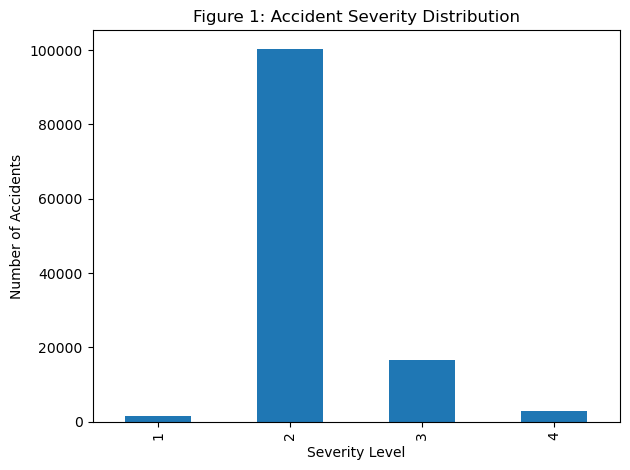

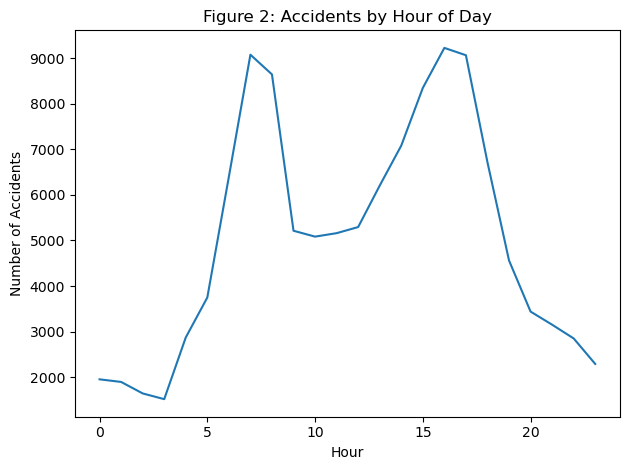

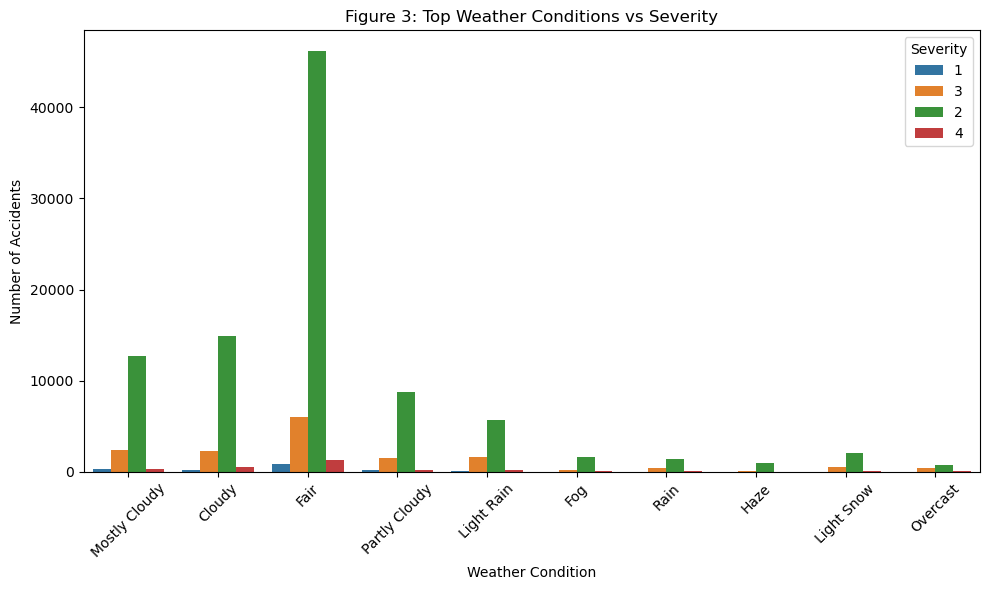

Training Logistic Regression...
Training Random Forest...
Training Gradient Boosting...

Model Performance Summary:
                 Model  Accuracy  Precision    Recall        F1
0  Logistic Regression  0.191641   0.750357  0.191641  0.238954
1        Random Forest  0.812806   0.719057  0.812806  0.750012
2    Gradient Boosting  0.826395   0.723743  0.826395  0.748569


<Figure size 640x480 with 0 Axes>

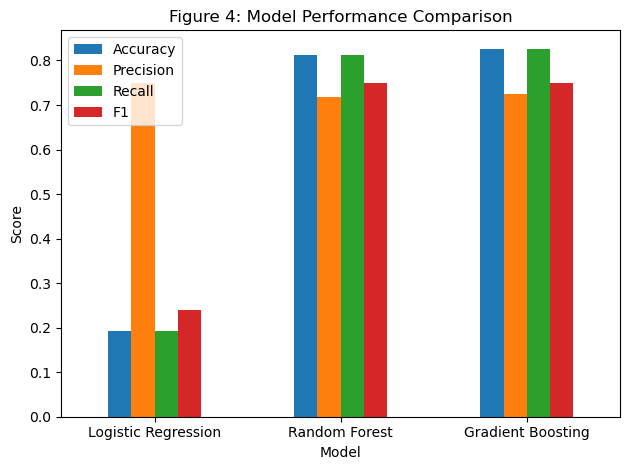

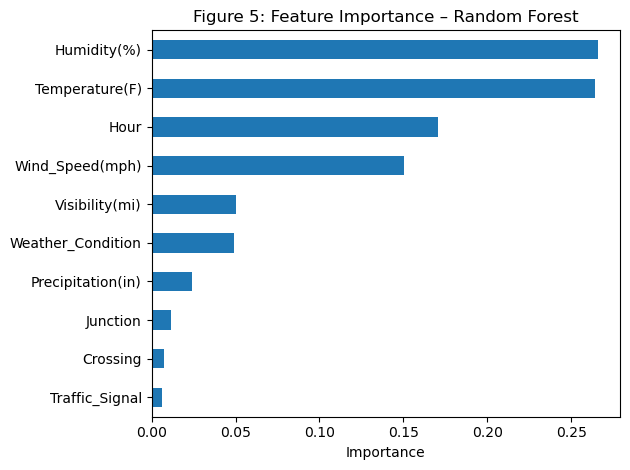


Classification Report - Gradient Boosting:
              precision    recall  f1-score   support

           1       0.50      0.01      0.03       311
           2       0.83      1.00      0.90     20073
           3       0.25      0.00      0.00      3298
           4       0.00      0.00      0.00       603

    accuracy                           0.83     24285
   macro avg       0.39      0.25      0.23     24285
weighted avg       0.72      0.83      0.75     24285


Confusion Matrix:
[[    4   307     0     0]
 [    4 20062     7     0]
 [    0  3295     3     0]
 [    0   601     2     0]]


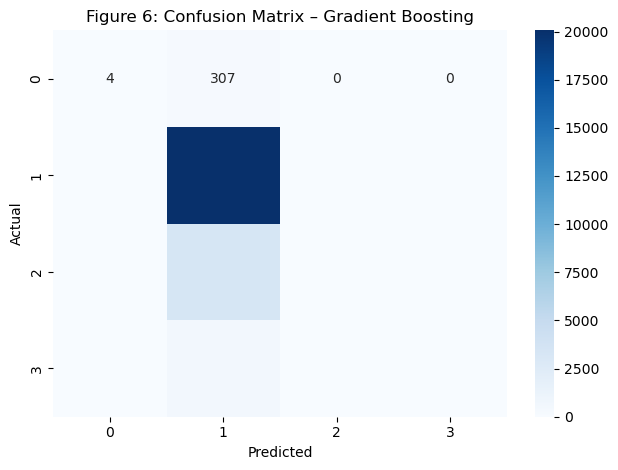


All visuals generated and saved in folder: Milestone3_Figures


In [2]:
"""
==========================================================
Project 2 – Final Code Submission (Milestone 3)
Predicting Traffic Accident Severity Using Machine Learning

Student: Arulsree Mozhi Thangaraj Santhakumar
Course: DSC680 – Applied Data Science
Instructor: Prof. Amirfarrokh Iranitalab

Dataset:
US Accidents (2016–present) – Kaggle
A sample of 200,000 records is used for computational efficiency.

Models Implemented:
1. Logistic Regression (with class balancing)
2. Random Forest
3. Gradient Boosting

Outputs:
- Model performance comparison (Accuracy, Precision, Recall, F1)
- Classification report
- Confusion matrix
- Six visualizations saved to output folder
==========================================================
"""

# ==========================================================
# 1. Import Libraries
# ==========================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Reproducibility
np.random.seed(42)

# ==========================================================
# 2. Create Folder for Figures
# ==========================================================
output_folder = "Milestone3_Figures"
os.makedirs(output_folder, exist_ok=True)

# ==========================================================
# 3. Load Dataset
# ==========================================================
file_path = "dataset_sample.csv"   # Update path if needed
df = pd.read_csv(file_path)

print("Original dataset shape:", df.shape)

# Sampling for faster processing
df = df.sample(n=200000, random_state=42)
print("Sampled dataset shape:", df.shape)

# ==========================================================
# 4. Select Relevant Columns
# ==========================================================
columns_needed = [
    'Severity', 'Start_Time', 'Temperature(F)', 'Humidity(%)',
    'Visibility(mi)', 'Wind_Speed(mph)', 'Precipitation(in)',
    'Weather_Condition', 'Traffic_Signal', 'Junction', 'Crossing'
]

df = df[columns_needed]

# ==========================================================
# 5. Data Preparation
# ==========================================================
df['Start_Time'] = pd.to_datetime(df['Start_Time'], errors='coerce')
df['Hour'] = df['Start_Time'].dt.hour

df = df.dropna()
print("After cleaning:", df.shape)

# ==========================================================
# VISUAL 1: Severity Distribution
# ==========================================================
plt.figure()
df['Severity'].value_counts().sort_index().plot(kind='bar')
plt.title("Figure 1: Accident Severity Distribution")
plt.xlabel("Severity Level")
plt.ylabel("Number of Accidents")
plt.tight_layout()
plt.savefig(os.path.join(output_folder, "Figure1_Severity_Distribution.png"), dpi=300)
plt.show()

# ==========================================================
# VISUAL 2: Accidents by Hour
# ==========================================================
plt.figure()
df.groupby('Hour').size().plot()
plt.title("Figure 2: Accidents by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Number of Accidents")
plt.tight_layout()
plt.savefig(os.path.join(output_folder, "Figure2_Hourly_Accidents.png"), dpi=300)
plt.show()

# ==========================================================
# VISUAL 3: Weather vs Severity
# ==========================================================
top_weather = df['Weather_Condition'].value_counts().nlargest(10).index
weather_df = df[df['Weather_Condition'].isin(top_weather)].copy()
weather_df['Severity'] = weather_df['Severity'].astype(str)

plt.figure(figsize=(10,6))
sns.countplot(data=weather_df, x='Weather_Condition', hue='Severity')
plt.xticks(rotation=45)
plt.title("Figure 3: Top Weather Conditions vs Severity")
plt.xlabel("Weather Condition")
plt.ylabel("Number of Accidents")
plt.tight_layout()
plt.savefig(os.path.join(output_folder, "Figure3_Weather_vs_Severity.png"), dpi=300)
plt.show()

# ==========================================================
# 6. Encoding and Feature Engineering
# ==========================================================
le = LabelEncoder()
df['Weather_Condition'] = le.fit_transform(df['Weather_Condition'])

df['Traffic_Signal'] = df['Traffic_Signal'].astype(int)
df['Junction'] = df['Junction'].astype(int)
df['Crossing'] = df['Crossing'].astype(int)

features = [
    'Temperature(F)', 'Humidity(%)', 'Visibility(mi)',
    'Wind_Speed(mph)', 'Precipitation(in)', 'Hour',
    'Weather_Condition', 'Traffic_Signal', 'Junction', 'Crossing'
]

X = df[features]
y = df['Severity']

# ==========================================================
# 7. Train-Test Split (Before Scaling)
# ==========================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale numeric features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ==========================================================
# 8. Model Training
# ==========================================================
models = {
    "Logistic Regression": LogisticRegression(max_iter=3000, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

results = []

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    results.append([
        name,
        accuracy_score(y_test, preds),
        precision_score(y_test, preds, average='weighted', zero_division=0),
        recall_score(y_test, preds, average='weighted'),
        f1_score(y_test, preds, average='weighted')
    ])

results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1"])
print("\nModel Performance Summary:")
print(results_df)

# ==========================================================
# VISUAL 4: Model Comparison
# ==========================================================
plt.figure()
results_df.set_index("Model").plot(kind='bar')
plt.title("Figure 4: Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(output_folder, "Figure4_Model_Comparison.png"), dpi=300)
plt.show()

# ==========================================================
# 9. Feature Importance (Random Forest)
# ==========================================================
rf_model = models["Random Forest"]
importances = rf_model.feature_importances_
feat_imp = pd.Series(importances, index=features).sort_values()

plt.figure()
feat_imp.plot(kind='barh')
plt.title("Figure 5: Feature Importance – Random Forest")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig(os.path.join(output_folder, "Figure5_Feature_Importance.png"), dpi=300)
plt.show()

# ==========================================================
# 10. Detailed Evaluation – Best Model (Gradient Boosting)
# ==========================================================
best_model = models["Gradient Boosting"]
y_pred_best = best_model.predict(X_test)

print("\nClassification Report - Gradient Boosting:")
print(classification_report(y_test, y_pred_best, zero_division=0))

cm = confusion_matrix(y_test, y_pred_best)
print("\nConfusion Matrix:")
print(cm)

# ==========================================================
# VISUAL 6: Confusion Matrix
# ==========================================================
plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Figure 6: Confusion Matrix – Gradient Boosting")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig(os.path.join(output_folder, "Figure6_Confusion_Matrix.png"), dpi=300)
plt.show()

print("\nAll visuals generated and saved in folder:", output_folder)
